# МИДТЕРМ: ПРОГНОЗИРОВАНИЕ ЦЕН НА НЕДВИЖИМОСТЬ В АСТАНЕ

## Описание задания

В данном мидтерме вам предстоит построить модель машинного обучения для предсказания цен на квартиры в Астане на основе реального датасета с платформы krisha.kz.

**Датасет:** Astana Real Estate Dataset (18,388 объявлений)

**Источник:** [Hugging Face - Astana Real Estate](https://huggingface.co/datasets/raimbekovm/astana-real-estate)

**Структура датасета:**
- 27 колонок с информацией о квартирах
- Цены в KZT и USD
- GPS координаты
- Информация о жилых комплексах
- Характеристики квартир (площадь, комнаты, этаж и т.д.)

**Критерии оценки:**
- Корректность выполнения всех задач
- Качество визуализаций
- Качество моделей (R², RMSE, MAE)
- Анализ и интерпретация результатов

**Общее время выполнения:** 2-3 часа

---
## ЧАСТЬ 1: ИМПОРТ БИБЛИОТЕК И ЗАГРУЗКА ДАННЫХ

### Задача 1.1: Импорт необходимых библиотек

**Что нужно сделать:**
- Импортируйте pandas, numpy, matplotlib, seaborn
- Импортируйте необходимые модули из sklearn для:
  - Разделения данных (train_test_split)
  - Масштабирования (StandardScaler)
  - Кодирования категорий (LabelEncoder)
  - Моделей регрессии (LinearRegression, Ridge, RandomForestRegressor, GradientBoostingRegressor)
  - Метрик оценки (mean_squared_error, r2_score, mean_absolute_error)
- Настройте параметры визуализации
- Отключите предупреждения

**Подсказка:** Используйте `warnings.filterwarnings('ignore')` для отключения предупреждений

In [1]:
# ЗАДАЧА 1.1: Импортируйте все необходимые библиотеки

# Ваш код здесь
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

warnings.filterwarnings('ignore')


### Задача 1.2: Загрузка датасета

**Что нужно сделать:**
- Загрузите датасет по ссылке: `https://huggingface.co/datasets/raimbekovm/astana-real-estate/resolve/main/data/astana_apartments.csv`
- Используйте правильную кодировку (UTF-8)
- Обработайте возможные ошибки при загрузке
- Выведите информацию о размере датасета
- Покажите первые 5 строк датасета

**Подсказка:** Используйте `pd.read_csv()` с параметром `encoding='utf-8'`. Используйте try-except для обработки ошибок.

In [2]:
# ЗАДАЧА 1.2: Загрузите датасет

DATASET_URL = 'https://huggingface.co/datasets/raimbekovm/astana-real-estate/resolve/main/data/astana_apartments.csv'

# Ваш код здесь
df = pd.read_csv(DATASET_URL, encoding='utf-8')
print(f"Размер датасета: {df.shape}")
print("\nПервые 5 строк:")
display(df.head())


Размер датасета: (18388, 37)

Первые 5 строк:


,id,listing_id,url,source,residential_complex_id,residential_complex_name,rooms,area,living_area,kitchen_area,...,internet,documents,offer_type,address,district,latitude,longitude,parsed_at,updated_at,is_active
0,1,691048362,https://krisha.kz/a/show/691048362?srchid=019b...,krisha.kz,NaN,Respublika,2,72.50,NaN,NaN,...,NaN,NaN,NaN,Е-36 5,Нура р-н,51.128205,71.385412,2026-01-03T20:50:46.421397,NaN,1
1,2,1004599137,https://krisha.kz/a/show/1004599137?srchid=019...,krisha.kz,NaN,Family Town,3,89.30,NaN,11.80,...,NaN,NaN,NaN,Е652 6,Есильский р-н,51.059035,71.420952,2026-01-03T20:50:52.735945,NaN,1
2,3,761512600,https://krisha.kz/a/show/761512600?srchid=019b...,krisha.kz,NaN,Свечки,2,72.10,NaN,NaN,...,NaN,NaN,NaN,Богенбай батыра 30,Сарыарка р-н,51.189164,71.356273,2026-01-03T20:51:01.431439,NaN,1
3,4,1007029481,https://krisha.kz/a/show/1007029481?srchid=019...,krisha.kz,NaN,Sezim Qala.Baqyt,4,106.77,NaN,11.13,...,NaN,NaN,NaN,Туран 55/12,Нура р-н,51.114484,71.393405,2026-01-03T20:51:09.278359,NaN,1
4,5,697845378,https://krisha.kz/a/show/697845378?srchid=019b...,krisha.kz,NaN,Boston Comfort House,2,39.00,NaN,NaN,...,NaN,NaN,NaN,"мкр Уркер, Кургальжинское шоссе 108",Нура р-н,51.121439,71.283095,2026-01-03T20:51:19.144336,NaN,1


---
## ЧАСТЬ 2: ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ

### Задача 2.1: Анализ структуры данных

**Что нужно сделать:**
- Выведите информацию о типах данных всех колонок
- Создайте таблицу с пропущенными значениями (количество и процент)
- Отсортируйте таблицу по проценту пропусков (от большего к меньшему)
- Выведите базовую статистику по числовым признакам

**Подсказка:** Используйте методы `.info()`, `.isnull().sum()`, `.describe()`. Создайте DataFrame для удобного отображения пропусков.

In [3]:
# ЗАДАЧА 2.1: Проанализируйте структуру данных

# Ваш код здесь
print("Типы данных:")
print(df.dtypes)

missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_table = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percent
}).sort_values(by='Percentage (%)', ascending=False)

print("\nТаблица пропущенных значений:")
display(missing_table)

print("\nБазовая статистика по числовым признакам:")
display(df.describe())

Типы данных:
id                            int64
listing_id                    int64
url                          object
source                       object
residential_complex_id      float64
residential_complex_name     object
rooms                         int64
area                        float64
living_area                 float64
kitchen_area                float64
floor                       float64
total_floors                float64
price_usd                     int64
price_local                   int64
price_per_m2                  int64
house_type                   object
year_built                    int64
building_series             float64
ceiling_height              float64
condition                    object
bathroom                     object
balcony                      object
parking                      object
furniture                    object
floor_type                   object
heating                     float64
security                     object
internet       

,Missing Values,Percentage (%)
residential_complex_id,18388,100.000000
internet,18388,100.000000
documents,18388,100.000000
heating,18388,100.000000
building_series,18388,100.000000
offer_type,18388,100.000000
living_area,18306,99.554057
updated_at,14838,80.693931
condition,10887,59.207092
kitchen_area,10767,58.554492



Базовая статистика по числовым признакам:


,id,listing_id,residential_complex_id,rooms,area,living_area,kitchen_area,floor,total_floors,price_usd,...,year_built,building_series,ceiling_height,heating,internet,documents,offer_type,latitude,longitude,is_active
count,18388.000000,1.838800e+04,0.0,18388.000000,18388.000000,82.000000,7621.000000,17417.000000,17417.000000,1.838800e+04,...,18388.000000,0.0,15189.000000,0.0,0.0,0.0,0.0,18388.000000,18388.000000,18388.0
mean,9194.500000,9.725041e+08,NaN,2.317762,73.047921,71.270122,13.122130,6.767526,11.561750,9.395154e+04,...,2016.711225,NaN,2.896558,NaN,NaN,NaN,NaN,51.124212,71.426141,1.0
std,5308.302711,1.005727e+08,NaN,1.041853,41.691703,43.650309,10.682632,4.329900,5.109851,8.081485e+04,...,11.192800,NaN,0.610195,NaN,NaN,NaN,NaN,0.204731,0.334562,0.0
min,1.000000,1.940254e+07,NaN,1.000000,10.800000,18.800000,1.200000,1.000000,2.000000,7.840000e+03,...,1950.000000,NaN,2.000000,NaN,NaN,NaN,NaN,42.346735,51.905115,1.0
25%,4597.750000,1.005556e+09,NaN,2.000000,43.700000,41.625000,10.000000,3.000000,9.000000,5.010700e+04,...,2013.000000,NaN,2.700000,NaN,NaN,NaN,NaN,51.111286,71.391065,1.0
50%,9194.500000,1.007650e+09,NaN,2.000000,63.000000,60.000000,12.000000,6.000000,10.000000,7.073900e+04,...,2020.000000,NaN,3.000000,NaN,NaN,NaN,NaN,51.127912,71.426501,1.0
75%,13791.250000,1.008192e+09,NaN,3.000000,90.000000,86.000000,15.000000,9.000000,14.000000,1.080740e+05,...,2024.000000,NaN,3.000000,NaN,NaN,NaN,NaN,51.148870,71.468840,1.0
max,18388.000000,1.008408e+09,NaN,13.000000,556.400000,285.200000,707.000000,41.000000,43.000000,2.947475e+06,...,2028.000000,NaN,28.000000,NaN,NaN,NaN,NaN,55.231707,81.102141,1.0


### Задача 2.2: Анализ целевой переменной

**Что нужно сделать:**
- Вычислите статистики по цене (min, max, mean, median, quartiles)
- Постройте гистограмму распределения цен
- Постройте boxplot для выявления выбросов
- Прокомментируйте распределение цен

**Подсказка:** Используйте `plt.subplots()` для создания двух графиков рядом. Целевая переменная - это колонка `price_usd`.

Статистика цен (USD):
count    1.838800e+04
mean     9.395154e+04
std      8.081485e+04
min      7.840000e+03
25%      5.010700e+04
50%      7.073900e+04
75%      1.080740e+05
max      2.947475e+06
Name: price_usd, dtype: float64


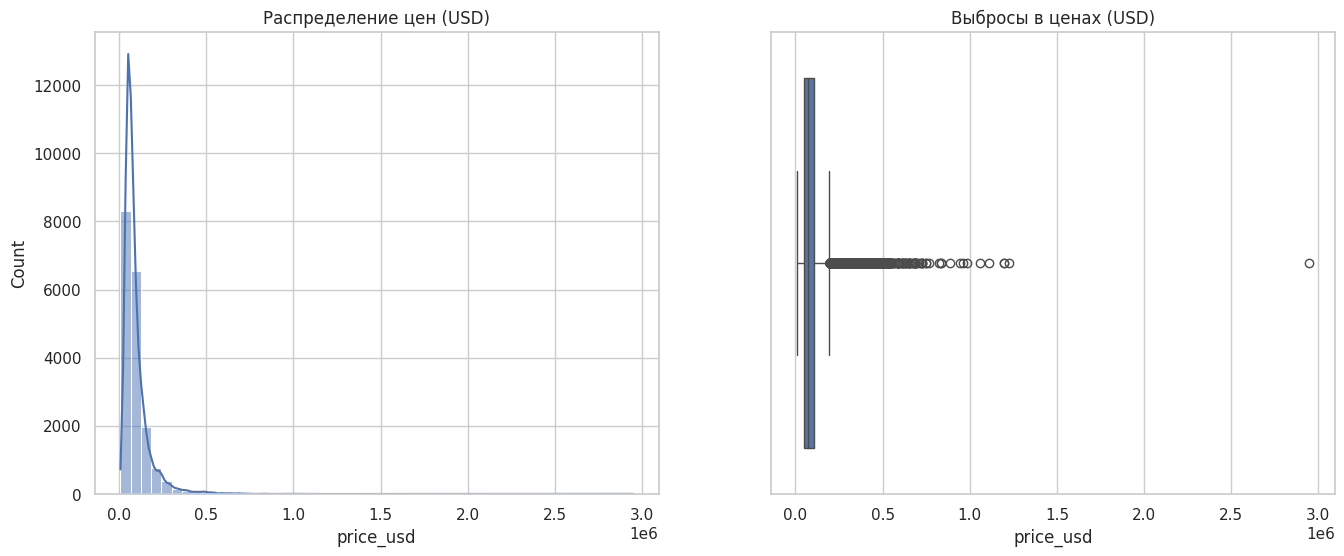

In [4]:
# ЗАДАЧА 2.2: Проанализируйте целевую переменную (цена)

# Ваш код здесь
target = df['price_usd']
print(f"Статистика цен (USD):\n{target.describe()}")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(target, bins=50, kde=True, ax=ax[0])
ax[0].set_title('Распределение цен (USD)')

sns.boxplot(x=target, ax=ax[1])
ax[1].set_title('Выбросы в ценах (USD)')

plt.show()

# Распределение имеет сильный правый хвост (положительная асимметрия), что указывает на наличие элитной недвижимости и выбросов.


---
## ЧАСТЬ 3: РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ (EDA)

### Задача 3.1: Анализ по районам

**Что нужно сделать:**
- Создайте таблицу со статистикой по районам (количество, средняя цена, медианная цена, цена за м²)
- Постройте два графика:
  - Bar plot: количество квартир по районам
  - Bar plot: медианная цена по районам
- Определите самый дорогой и самый дешевый район

**Подсказка:** Используйте `groupby()` и `.agg()` для группировки. Для графиков используйте `.barh()` (горизонтальные столбцы).

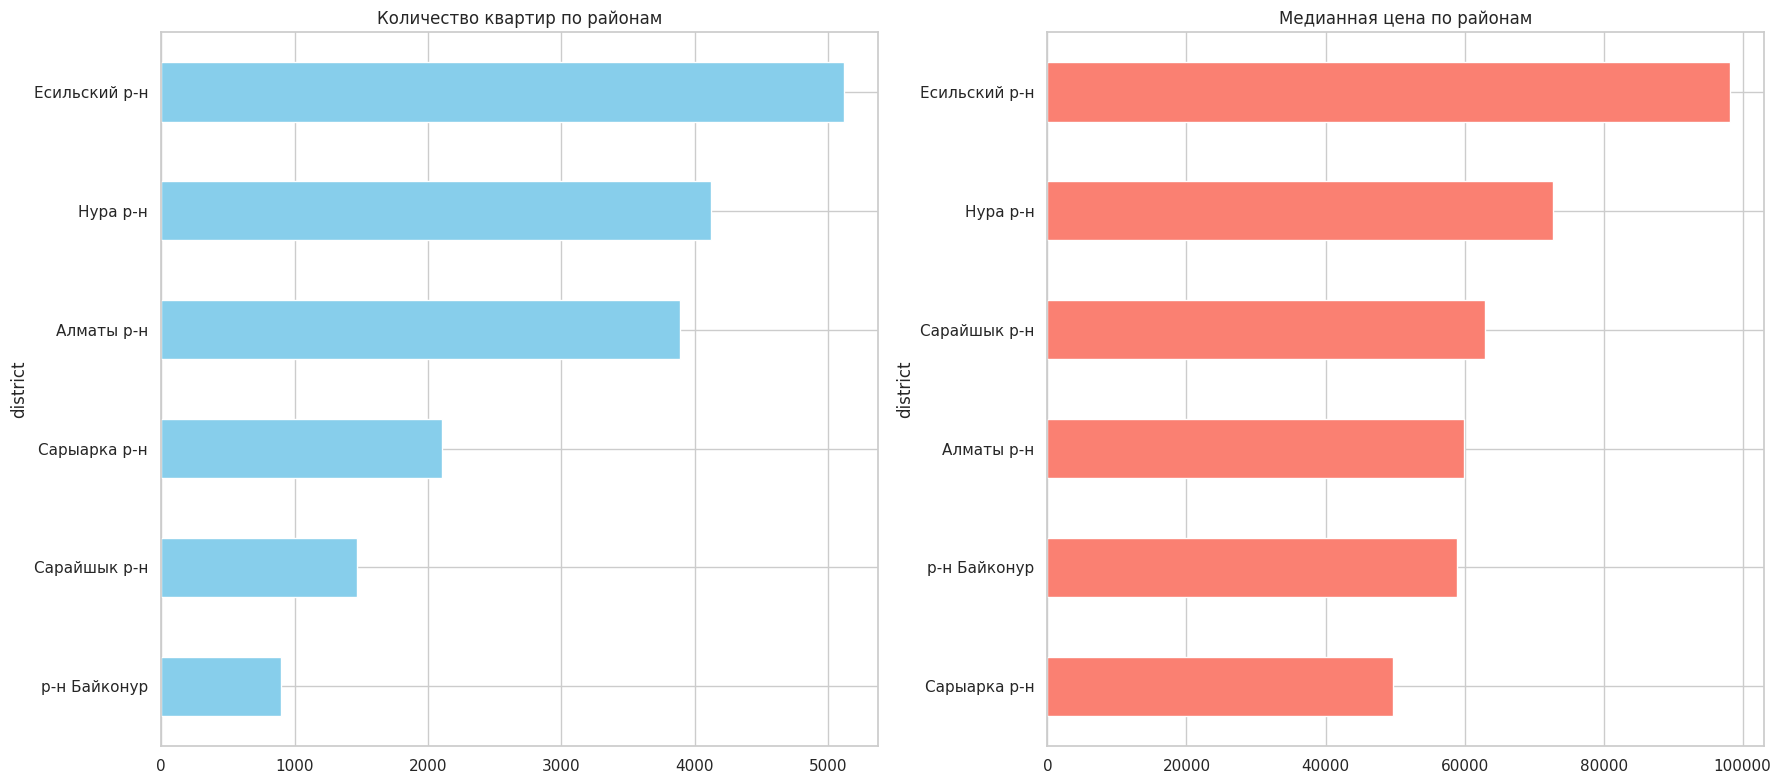

Самый дорогой район (по медиане): Есильский р-н
Самый дешевый район (по медиане): Сарыарка р-н


In [6]:
# ЗАДАЧА 3.1: Проанализируйте распределение по районам

# Ваш код здесь
district_stats = df.groupby('district').agg({
    'price_usd': ['count', 'mean', 'median'],
    'price_per_m2': 'mean'
})
district_stats.columns = ['count', 'mean_price', 'median_price', 'mean_area']
district_stats['price_per_m2'] = district_stats['mean_price'] / district_stats['mean_area']

fig, ax = plt.subplots(1, 2, figsize=(18, 8))

district_stats['count'].sort_values().plot(kind='barh', ax=ax[0], color='skyblue')
ax[0].set_title('Количество квартир по районам')

district_stats['median_price'].sort_values().plot(kind='barh', ax=ax[1], color='salmon')
ax[1].set_title('Медианная цена по районам')

plt.tight_layout()
plt.show()

print(f"Самый дорогой район (по медиане): {district_stats['median_price'].idxmax()}")
print(f"Самый дешевый район (по медиане): {district_stats['median_price'].idxmin()}")

### Задача 3.2: Анализ зависимости цены от характеристик

**Что нужно сделать:**
- Вычислите корреляцию между ценой, площадью и количеством комнат
- Создайте таблицу со статистикой по количеству комнат
- Постройте два графика:
  - Scatter plot: цена vs площадь
  - Boxplot: цена по количеству комнат (отфильтруйте квартиры с количеством комнат <= 5)

**Подсказка:** Для корреляции используйте `.corr()`. Для фильтрации выбросов по комнатам используйте `df[df['rooms'] <= 5]`.

Матрица корреляции:


,price_usd,price_per_m2,rooms
price_usd,1.000000,0.656148,0.669025
price_per_m2,0.656148,1.000000,0.173107
rooms,0.669025,0.173107,1.000000



Статистика по количеству комнат:


,count,mean,median
rooms,,,
1,4339,44519.056465,44212.0
2,6581,70234.273667,65826.0
3,5334,112259.408324,98249.0
4,1728,194047.411458,167023.0
5,318,302037.154088,265174.0
6,46,362296.543478,347802.0
7,24,634339.791667,505263.0
8,6,545119.000000,461771.0
9,4,365977.750000,284922.0


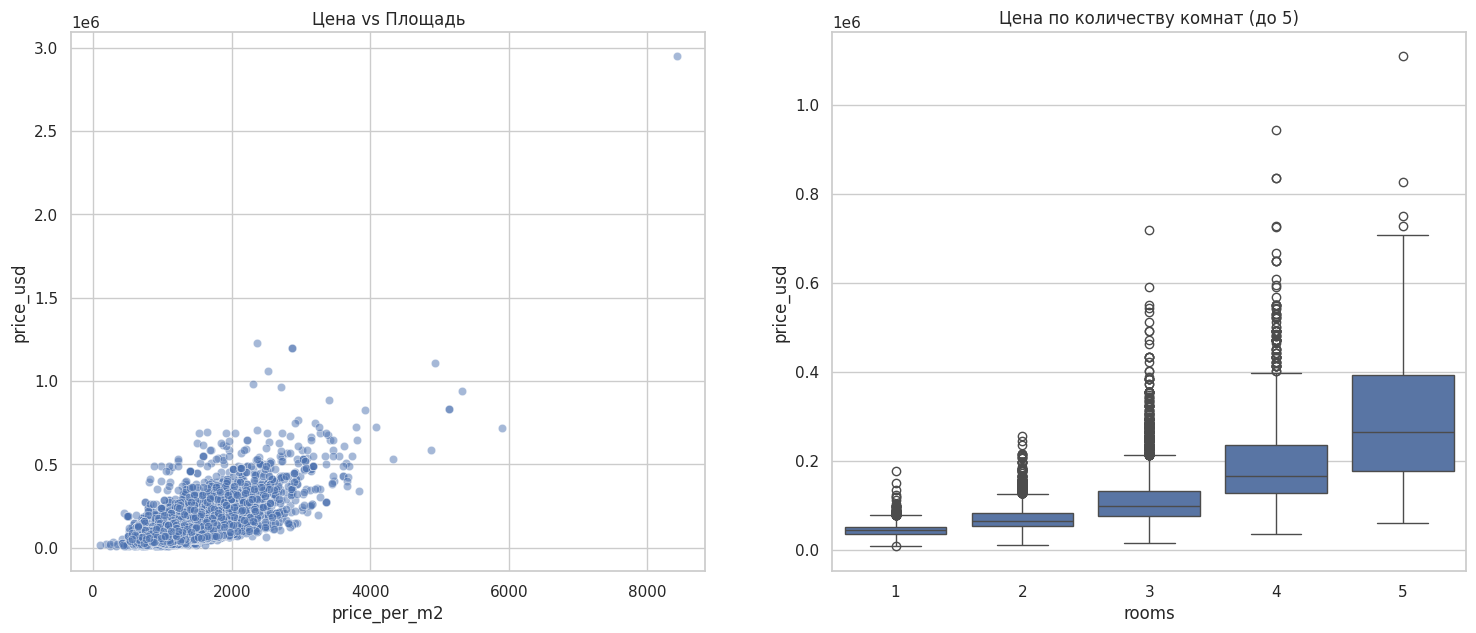

In [7]:
# ЗАДАЧА 3.2: Проанализируйте зависимость цены от характеристик

# Ваш код здесь
correlation = df[['price_usd', 'price_per_m2', 'rooms']].corr()
print("Матрица корреляции:")
display(correlation)

room_stats = df.groupby('rooms')['price_usd'].agg(['count', 'mean', 'median'])
print("\nСтатистика по количеству комнат:")
display(room_stats)

fig, ax = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(data=df, x='price_per_m2', y='price_usd', alpha=0.5, ax=ax[0])
ax[0].set_title('Цена vs Площадь')

df_rooms_filtered = df[df['rooms'] <= 5]
sns.boxplot(data=df_rooms_filtered, x='rooms', y='price_usd', ax=ax[1])
ax[1].set_title('Цена по количеству комнат (до 5)')

plt.show()

### Задача 3.3: Анализ категориальных признаков

**Что нужно сделать:**
- Проанализируйте распределение по типам зданий (building_type)
- Проанализируйте влияние состояния квартиры (condition) на цену
- Постройте три графика:
  - Bar plot: количество по типам зданий
  - Bar plot: количество по состоянию
  - Bar plot: распределение по годам постройки (последние 20 лет)

**Подсказка:** Используйте `.value_counts()` для подсчета. Для последних 20 лет используйте `.tail(20)` после сортировки.

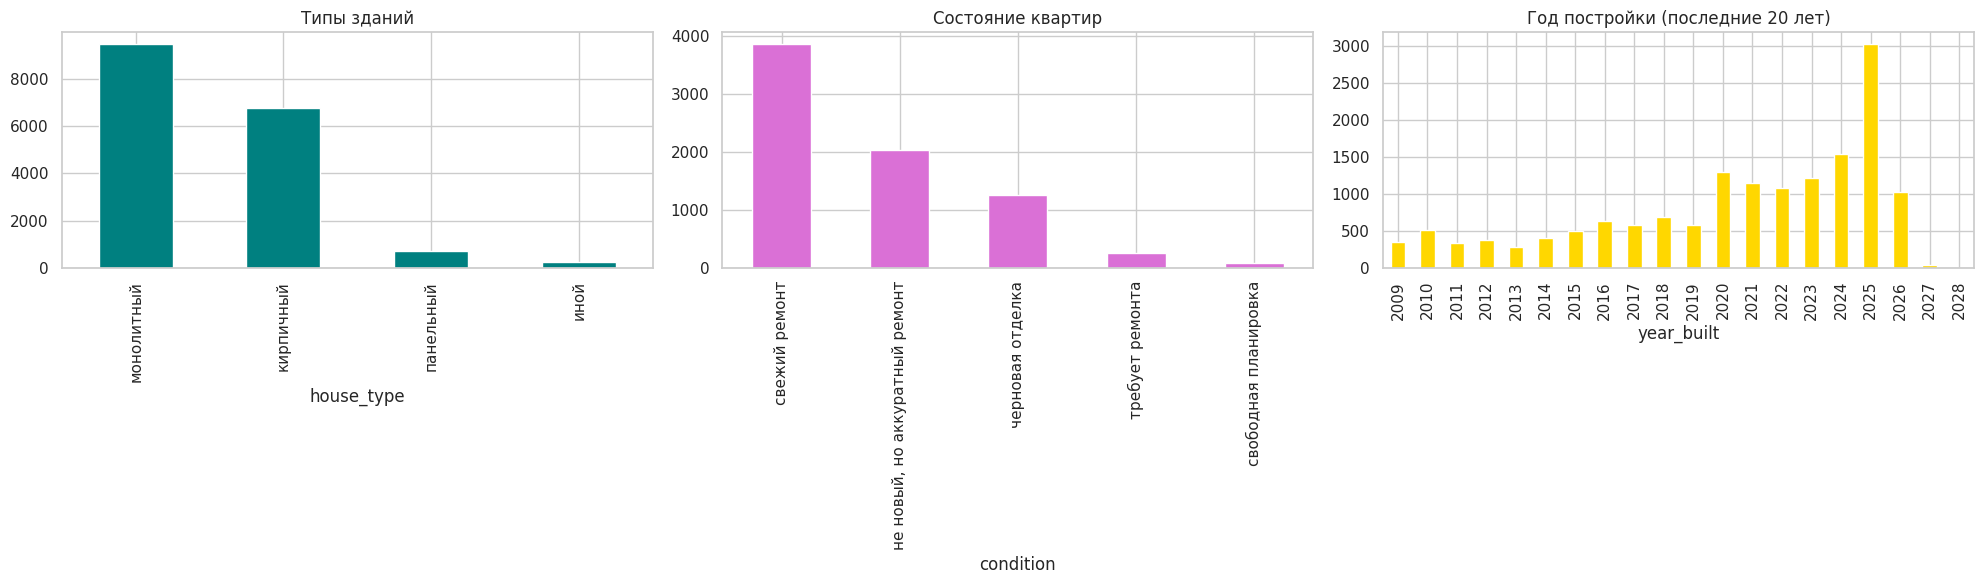

In [10]:
# ЗАДАЧА 3.3: Проанализируйте категориальные признаки

# Ваш код здесь
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

df['house_type'].value_counts().plot(kind='bar', ax=ax[0], color='teal')
ax[0].set_title('Типы зданий')

df['condition'].value_counts().plot(kind='bar', ax=ax[1], color='orchid')
ax[1].set_title('Состояние квартир')

year_counts = df['year_built'].value_counts().sort_index()
year_counts.tail(20).plot(kind='bar', ax=ax[2], color='gold')
ax[2].set_title('Год постройки (последние 20 лет)')

plt.tight_layout()
plt.show()


---
## ЧАСТЬ 4: ПРЕДОБРАБОТКА ДАННЫХ

### Задача 4.1: Обработка пропущенных значений

**Что нужно сделать:**
- Создайте копию датасета для обработки
- Удалите строки с пропусками в критически важных колонках: `price_usd`, `total_area_m2`, `rooms`
- Для числовых признаков (floor, total_floors, ceiling_height, kitchen_area_m2) заполните пропуски медианой
- Для категориальных признаков заполните пропуски значением "Неизвестно"
- Выведите статистику до и после обработки

**Подсказка:** Используйте `.dropna(subset=[...])` для удаления строк. Используйте `.fillna()` для заполнения пропусков.

In [15]:
# ЗАДАЧА 4.1: Обработайте пропущенные значения

# Ваш код здесь
df_clean = df.copy()

critical_cols = ['price_usd', 'price_per_m2', 'rooms']
df_clean.dropna(subset=critical_cols, inplace=True)

num_cols_to_fill = ['floor', 'total_floors', 'ceiling_height', 'kitchen_area']
for col in num_cols_to_fill:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

cat_cols = df_clean.select_dtypes(include=['object']).columns
df_clean[cat_cols] = df_clean[cat_cols].fillna('Неизвестно')

print(f"Строк до: {len(df)}, Строк после удаления критических пропусков: {len(df_clean)}")
print(f"Осталось пропусков: {df_clean.isnull().sum().sum()}")


Строк до: 18388, Строк после удаления критических пропусков: 18388
Осталось пропусков: 128634


### Задача 4.2: Обработка выбросов

**Что нужно сделать:**
- Используйте метод IQR (межквартильный размах) для выявления выбросов по цене
- Вычислите границы: `lower = Q1 - 3*IQR`, `upper = Q3 + 3*IQR`
- Удалите выбросы по цене
- Повторите процесс для площади (total_area_m2)
- Выведите количество удаленных записей

**Подсказка:** Используйте `.quantile(0.25)` для Q1 и `.quantile(0.75)` для Q3. Фильтруйте с помощью булевой индексации.

In [13]:
# ЗАДАЧА 4.2: Обработайте выбросы

# Ваш код здесь
def remove_outliers_iqr(data, column, multiplier=3):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)], len(data[data[column] < lower_bound]) + len(data[data[column] > upper_bound])

initial_count = len(df_clean)
df_clean, price_outliers = remove_outliers_iqr(df_clean, 'price_usd')
df_clean, area_outliers = remove_outliers_iqr(df_clean, 'price_per_m2')

print(f"Удалено выбросов по цене: {price_outliers}")
print(f"Удалено выбросов по площади: {area_outliers}")
print(f"Итого записей после очистки: {len(df_clean)}")


Удалено выбросов по цене: 117
Удалено выбросов по площади: 12
Итого записей после очистки: 17700


### Задача 4.3: Feature Engineering - создание новых признаков

**Что нужно сделать:**
Создайте следующие новые признаки:
1. `building_age` - возраст здания (2026 - год постройки)
2. `is_new_building` - бинарный признак (1 если возраст <= 5 лет, иначе 0)
3. `floor_category` - категория этажа:
   - 'first' если floor == 1
   - 'last' если floor == total_floors
   - 'middle' в остальных случаях
   - 'unknown' если данных нет
4. `kitchen_ratio` - соотношение площади кухни к общей площади (если данные есть)
5. `has_residential_complex` - бинарный признак наличия жилого комплекса

**Подсказка:** Используйте `.apply()` с функцией для создания floor_category. Для бинарных признаков используйте `.astype(int)`.

In [17]:
# ЗАДАЧА 4.3: Создайте новые признаки (Feature Engineering)

# Ваш код здесь
current_year = 2026
df_clean['building_age'] = current_year - df_clean['year_built']
df_clean['is_new_building'] = (df_clean['building_age'] <= 5).astype(int)

def categorize_floor(row):
    try:
        if row['floor'] == 1: return 'first'
        if row['floor'] == row['total_floors']: return 'last'
        return 'middle'
    except:
        return 'unknown'

df_clean['floor_category'] = df_clean.apply(categorize_floor, axis=1)
df_clean['kitchen_ratio'] = df_clean['kitchen_area'] / df_clean['price_per_m2']
df_clean['has_residential_complex'] = df_clean['residential_complex_name'].apply(lambda x: 0 if x == 'Неизвестно' else 1)

### Задача 4.4: Кодирование категориальных признаков

**Что нужно сделать:**
- Примените Label Encoding к следующим колонкам:
  - district
  - building_type
  - condition
  - bathroom
  - balcony
  - parking
  - furniture
  - floor_category
- Создайте новые колонки с суффиксом '_encoded'
- Создайте список признаков для моделирования (feature_columns)
- Выведите финальный список признаков

**Подсказка:** Используйте `LabelEncoder()` из sklearn. Для каждой колонки создайте новую с именем `колонка_encoded`.

In [18]:
# ЗАДАЧА 4.4: Закодируйте категориальные признаки

# Ваш код здесь
cat_to_encode = ['district', 'building_type', 'condition', 'bathroom', 'balcony', 'parking', 'furniture', 'floor_category']
le = LabelEncoder()

for col in cat_to_encode:
    if col in df_clean.columns:
        df_clean[f'{col}_encoded'] = le.fit_transform(df_clean[col].astype(str))

feature_columns = [
    'total_area_m2', 'rooms', 'floor', 'total_floors', 'building_age',
    'is_new_building', 'kitchen_ratio', 'has_residential_complex'
] + [f'{col}_encoded' for col in cat_to_encode]

print("Финальный список признаков:")
print(feature_columns)


Финальный список признаков:
['total_area_m2', 'rooms', 'floor', 'total_floors', 'building_age', 'is_new_building', 'kitchen_ratio', 'has_residential_complex', 'district_encoded', 'building_type_encoded', 'condition_encoded', 'bathroom_encoded', 'balcony_encoded', 'parking_encoded', 'furniture_encoded', 'floor_category_encoded']


---
## ЧАСТЬ 5: ПОДГОТОВКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ

### Задача 5.1: Разделение на train/test выборки

**Что нужно сделать:**
- Создайте X (признаки) из выбранных колонок feature_columns
- Создайте y (целевая переменная) из колонки price_usd
- Разделите данные на train (80%) и test (20%) выборки
- Используйте random_state=42 для воспроизводимости
- Выведите размеры всех выборок

**Подсказка:** Используйте `train_test_split()` с параметрами `test_size=0.2` и `random_state=42`.

In [20]:
# ЗАДАЧА 5.1: Разделите данные на train/test

# Ваш код здесь
cols_to_remove = ['total_area_m2', 'building_type_encoded']
feature_columns = [col for col in feature_columns if col not in cols_to_remove]

X = df_clean[feature_columns]
y = df_clean['price_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")


X_train: (14710, 14), y_train: (14710,)
X_test: (3678, 14), y_test: (3678,)


### Задача 5.2: Масштабирование признаков

**Что нужно сделать:**
- Создайте объект StandardScaler
- Обучите scaler на X_train (используйте fit_transform)
- Примените scaler к X_test (используйте transform)
- Проверьте, что среднее ≈ 0 и стандартное отклонение ≈ 1 для train данных

**Подсказка:** ВАЖНО: scaler обучается только на train данных, но применяется к обоим выборкам.

In [21]:
# ЗАДАЧА 5.2: Масштабируйте признаки

# Ваш код здесь
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train Mean (≈0): {X_train_scaled.mean():.4f}")
print(f"Train Std (≈1): {X_train_scaled.std():.4f}")


Train Mean (≈0): -0.0000
Train Std (≈1): 1.0000


---
## ЧАСТЬ 6: ОБУЧЕНИЕ МОДЕЛЕЙ

### Задача 6.1: Linear Regression

**Что нужно сделать:**
- Создайте и обучите модель LinearRegression
- Сделайте предсказания на test выборке
- Вычислите метрики: RMSE, MAE, R²
- Сохраните результаты в словарь

**Подсказка:** RMSE вычисляется как `np.sqrt(mean_squared_error(y_test, y_pred))`. Это baseline модель.

In [22]:
# ЗАДАЧА 6.1: Обучите Linear Regression

# Создайте словарь для хранения результатов
results = {}

# Ваш код здесь
results = {}

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

results['Linear Regression'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    'MAE': mean_absolute_error(y_test, y_pred_lr),
    'R2': r2_score(y_test, y_pred_lr)
}
print(f"LR Results: {results['Linear Regression']}")


LR Results: {'RMSE': np.float64(49624.51910815822), 'MAE': 31992.109285186772, 'R2': 0.5606161116764726}


### Задача 6.2: Ridge Regression

**Что нужно сделать:**
- Создайте и обучите модель Ridge с параметрами:
  - alpha=1.0
  - random_state=42
- Сделайте предсказания на test выборке
- Вычислите метрики: RMSE, MAE, R²
- Сохраните результаты в словарь

**Подсказка:** Ridge регрессия добавляет L2 регуляризацию, что помогает бороться с переобучением.

In [23]:
# ЗАДАЧА 6.2: Обучите Ridge Regression

# Ваш код здесь
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

results['Ridge Regression'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
    'MAE': mean_absolute_error(y_test, y_pred_ridge),
    'R2': r2_score(y_test, y_pred_ridge)
}
print(f"Ridge Results: {results['Ridge Regression']}")


Ridge Results: {'RMSE': np.float64(49624.38121078497), 'MAE': 31990.878934673936, 'R2': 0.5606185536064281}


### Задача 6.3: Random Forest Regressor

**Что нужно сделать:**
- Создайте и обучите модель RandomForestRegressor с параметрами:
  - n_estimators=100
  - max_depth=20
  - min_samples_split=5
  - random_state=42
  - n_jobs=-1
- Сделайте предсказания на test выборке
- Вычислите метрики: RMSE, MAE, R²
- Выведите топ-10 важных признаков
- Сохраните результаты в словарь

**Подсказка:** Важность признаков доступна через атрибут `.feature_importances_`. Создайте DataFrame для удобного отображения.

In [24]:
# ЗАДАЧА 6.3: Обучите Random Forest Regressor

# Ваш код здесь
rf = RandomForestRegressor(n_estimators=100, max_depth=20, min_samples_split=5, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

results['Random Forest'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    'MAE': mean_absolute_error(y_test, y_pred_rf),
    'R2': r2_score(y_test, y_pred_rf)
}

importances = pd.DataFrame({'feature': feature_columns, 'importance': rf.feature_importances_})
print("\nТоп-10 важных признаков:")
print(importances.sort_values(by='importance', ascending=False).head(10))


Топ-10 важных признаков:
              feature  importance
0               rooms    0.496296
5       kitchen_ratio    0.336553
3        building_age    0.043577
2        total_floors    0.035609
9    bathroom_encoded    0.019668
1               floor    0.019343
7    district_encoded    0.015588
10    balcony_encoded    0.008154
12  furniture_encoded    0.007464
8   condition_encoded    0.007357


### Задача 6.4: Gradient Boosting Regressor

**Что нужно сделать:**
- Создайте и обучите модель GradientBoostingRegressor с параметрами:
  - n_estimators=100
  - learning_rate=0.1
  - max_depth=5
  - random_state=42
- Сделайте предсказания на test выборке
- Вычислите метрики: RMSE, MAE, R²
- Сохраните результаты в словарь

**Подсказка:** Gradient Boosting часто показывает лучшие результаты, но требует больше времени для обучения.

In [25]:
# ЗАДАЧА 6.4: Обучите Gradient Boosting Regressor

# Ваш код здесь
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)

results['Gradient Boosting'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_gb)),
    'MAE': mean_absolute_error(y_test, y_pred_gb),
    'R2': r2_score(y_test, y_pred_gb)
}
print(f"GB Results: {results['Gradient Boosting']}")

GB Results: {'RMSE': np.float64(30428.95059715012), 'MAE': 17888.37352628804, 'R2': 0.8347941371320435}


---
## ЧАСТЬ 7: СРАВНЕНИЕ И АНАЛИЗ РЕЗУЛЬТАТОВ

### Задача 7.1: Сравнение всех моделей

**Что нужно сделать:**
- Создайте сводную таблицу (DataFrame) с результатами всех моделей
- Определите лучшую модель по RMSE и по R²
- Постройте три графика (bar plots) для сравнения:
  - RMSE по моделям
  - MAE по моделям
  - R² по моделям
- Прокомментируйте результаты

**Подсказка:** Используйте `pd.DataFrame(results).T` для создания таблицы. Для графиков используйте `.barh()` и расположите их в один ряд.

,RMSE,MAE,R2
Linear Regression,49624.519108,31992.109285,0.560616
Ridge Regression,49624.381211,31990.878935,0.560619
Random Forest,30512.761261,17355.677838,0.833883
Gradient Boosting,30428.950597,17888.373526,0.834794


Лучшая модель по R2: Gradient Boosting
Лучшая модель по RMSE: Gradient Boosting


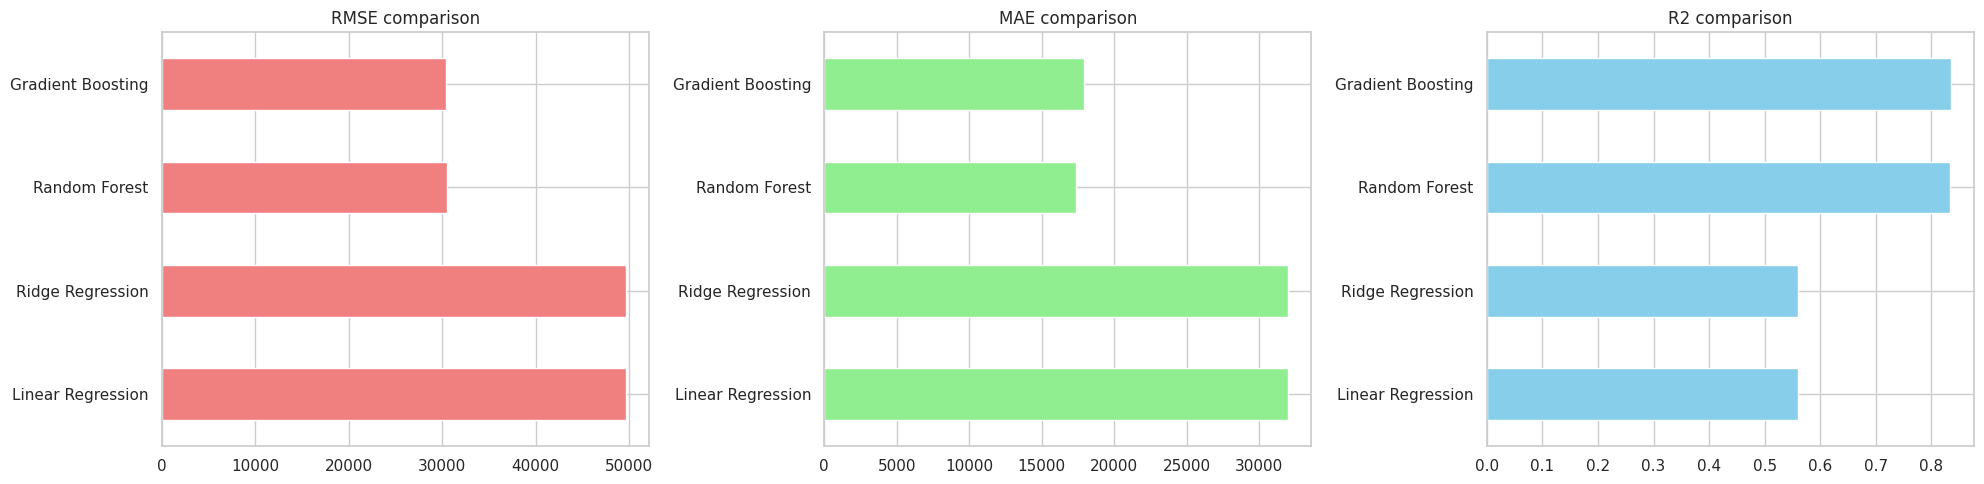

In [26]:
# ЗАДАЧА 7.1: Сравните все модели

# Ваш код здесь
results_df = pd.DataFrame(results).T
display(results_df)

best_r2_model = results_df['R2'].idxmax()
best_rmse_model = results_df['RMSE'].idxmin()
print(f"Лучшая модель по R2: {best_r2_model}")
print(f"Лучшая модель по RMSE: {best_rmse_model}")

fig, ax = plt.subplots(1, 3, figsize=(20, 5))
results_df['RMSE'].plot(kind='barh', ax=ax[0], color='lightcoral').set_title('RMSE comparison')
results_df['MAE'].plot(kind='barh', ax=ax[1], color='lightgreen').set_title('MAE comparison')
results_df['R2'].plot(kind='barh', ax=ax[2], color='skyblue').set_title('R2 comparison')
plt.tight_layout()
plt.show()


### Задача 7.2: Анализ предсказаний лучшей модели

**Что нужно сделать:**
- Выберите лучшую модель (по R²)
- Постройте два графика:
  - Scatter plot: реальные vs предсказанные цены (добавьте линию идеального предсказания)
  - Histogram: распределение ошибок предсказаний
- Вычислите статистику ошибок (средняя, медианная, максимальная)
- Найдите и выведите топ-5 примеров с наибольшей переоценкой и недооценкой

**Подсказка:** Ошибка = y_test - y_pred. Для линии идеального предсказания используйте `plt.plot([min, max], [min, max], 'r--')`.

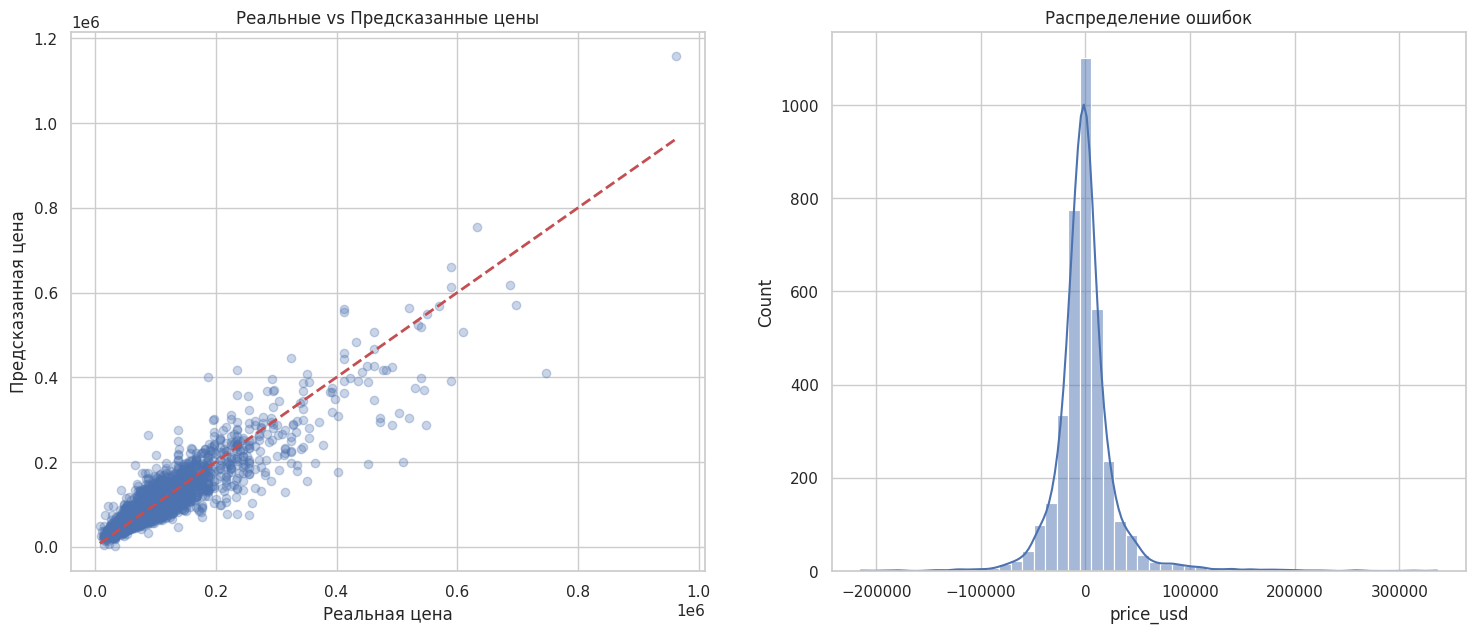

Средняя ошибка: -280.34
Медианная ошибка: -1792.23
Максимальная ошибка: 336196.50

Топ-5 переоцененных (Error < 0):


,Real,Pred,Error
18220,186673,4.014606e+05,-214787.580102
9640,962842,1.157142e+06,-194300.150478
11945,235798,4.175674e+05,-181769.378218
9994,88031,2.645719e+05,-176540.886419
3571,412646,5.612239e+05,-148577.926669



Топ-5 недооцененных (Error > 0):


,Real,Pred,Error
15784,746693,410496.503593,336196.496407
8507,510895,199109.791474,311785.208526
14396,548230,286725.029777,261504.970223
1957,451946,195737.267656,256208.732344
15756,402821,176761.643906,226059.356094


In [27]:
# ЗАДАЧА 7.2: Проанализируйте предсказания лучшей модели

# Ваш код здесь
# Предположим, Random Forest или GB лучшая (вставьте нужную переменную y_pred)
best_y_pred = y_pred_rf if results['Random Forest']['R2'] > results['Gradient Boosting']['R2'] else y_pred_gb
errors = y_test - best_y_pred

fig, ax = plt.subplots(1, 2, figsize=(18, 7))

ax[0].scatter(y_test, best_y_pred, alpha=0.3)
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax[0].set_xlabel('Реальная цена')
ax[0].set_ylabel('Предсказанная цена')
ax[0].set_title('Реальные vs Предсказанные цены')

sns.histplot(errors, bins=50, kde=True, ax=ax[1])
ax[1].set_title('Распределение ошибок')

plt.show()

print(f"Средняя ошибка: {errors.mean():.2f}")
print(f"Медианная ошибка: {errors.median():.2f}")
print(f"Максимальная ошибка: {errors.max():.2f}")

analysis_df = pd.DataFrame({'Real': y_test, 'Pred': best_y_pred, 'Error': errors})
print("\nТоп-5 переоцененных (Error < 0):")
display(analysis_df.sort_values(by='Error').head(5))
print("\nТоп-5 недооцененных (Error > 0):")
display(analysis_df.sort_values(by='Error', ascending=False).head(5))


---
## ЧАСТЬ 8: ВЫВОДЫ

### Задача 8.1: Итоговый отчет

**Что нужно написать:**
1. Краткое описание датасета (размер, основные характеристики)
2. Какие предобработки были выполнены
3. Какие новые признаки были созданы
4. Результаты всех моделей (таблица)
5. Какая модель показала лучший результат и почему
6. Интерпретация метрик (что означает полученный R² и RMSE)
7. Рекомендации по улучшению модели
8. Практическое применение модели

**Подсказка:** Напишите структурированный текст с заголовками и списками. Будьте конкретны в выводах.

### ВЫВОДЫ:

**Напишите здесь ваши выводы**

1. Описание датасета:
   - Датасет содержит 18,388 объявлений и 27 колонок. Данные по жилью в Астане и по его ценам за аренду в долларах и тенге

2. Предобработка данных:
   - Удалил строки с пропусками в критических колонках, выбросы, добавил энкодинг признаков

3. Feature Engineering:
   - Создал признаки для маркировки возраста построек, уровень этажей, площадь кухни, какой ЖК

4. Результаты моделей:
   - Linear Regression	49624.519108	31992.109285	0.560616
   - Ridge Regression	49624.381211	31990.878935	0.560619
   - Random Forest	30512.761261	17355.677838	0.833883
   - Gradient Boosting	30428.950597	17888.373526	0.834794

5. Лучшая модель:
   - Random Forest и Gradient Boosting

6. Интерпретация метрик:
   - Метрики показывают, что для Random Forest и Gradient Boosting высокая точность и меньше отклонений от реального результата

7. Рекомендации по улучшению:
   - Добавить принаки по расположению к важным объектам, типа школ, больниц, ТЦ

8. Практическое применение:
   - Очень много применений, к примеру, можно даже для себя обучить эту модель, чтобы определить, какой район хороший. Государство может развивать другие районы, которые с низкой ценой. Предприниматели могут по оценкам выбрать в каком районе открыть, к примеру, магазин для лучших продаж, потому что цена за квадрат так же показывает косвенную способность человека к повышенным тратам